# Huy Dung · ADY201m · Đánh giá phân loại và sai số dự đoán
**Phiên bản HD-2026.** Thực thi cục bộ với SQLite theo phương án đã được phép sử dụng.
Câu hỏi mở rộng: tỷ lệ CARDIO theo nhóm tuổi, sự đánh đổi precision–recall và sai số theo mã giới tính.
Random Forest được tinh chỉnh trên tập train bằng F1, 5 fold; tập test chỉ dùng sau khi hoàn tất chọn tham số.
Kết quả là phân tích bài tập trên dữ liệu quan sát; không diễn giải thành quan hệ nhân quả hoặc chỉ định y khoa.

## 1. Nguồn dữ liệu và thiết kế nghiên cứu
70.000 hồ sơ khôi phục từ PDF dữ liệu của đề. ID bị loại khỏi mô hình; AGE chuyển từ ngày sang năm nguyên.
Giữ nguyên 11 đặc trưng để đáp ứng đề. Các hồ sơ trùng đặc trưng được giữ do ID riêng; cần lưu ý khi đánh giá tổng quát hóa.
Dữ liệu và kiểm định cơ bản giống phiên bản trước vì cùng nguồn; mô hình và đánh giá được chạy lại.

In [1]:
from pathlib import Path
import json, time, platform, importlib.metadata as metadata
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Image
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import (RandomForestClassifier,GradientBoostingClassifier,
    AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,StackingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,confusion_matrix,classification_report,balanced_accuracy_score,
    average_precision_score,brier_score_loss,roc_curve,precision_recall_curve)
from cardio_utils import IQRClipper
import joblib
ROOT=Path.cwd()
for folder in ['results','figures','data']: (ROOT/folder).mkdir(exist_ok=True)
RAW=ROOT/'data/cardio_train_raw.csv'
if not RAW.exists(): RAW=ROOT/'cardio_train_raw.csv'
raw=pd.read_csv(RAW,sep=';')
assert raw.shape==(70000,13) and raw.id.nunique()==70000
assert not raw.isna().any().any()
df=raw.copy()
df['age']=df['age']//365
features=['age','gender','height','weight','ap_hi','ap_lo','cholesterol','gluc','smoke','alco','active']
sns.set_theme(style='ticks',palette='mako')
SEED=2026
from statsmodels.stats.proportion import proportion_confint
from sklearn.calibration import calibration_curve
def figure(name):
    plt.tight_layout()
    path=ROOT/'figures'/name
    plt.savefig(path,dpi=150,bbox_inches='tight')
    plt.close()
    display(Image(filename=str(path)))
quality={'rows':len(df),'columns':len(df.columns),'unique_ids':int(df.id.nunique()),
    'missing_values':int(df.isna().sum().sum()),'duplicate_feature_target_rows':int(df.drop(columns='id').duplicated().sum()),
    'disease_cases':int(df.cardio.sum()),'disease_rate':float(df.cardio.mean())}
display(pd.Series(quality,name='Kết quả kiểm tra'))
display(df.head(10))
display(df.describe().T)
df.describe().T.to_csv(ROOT/'results/descriptive_statistics.csv')
(ROOT/'results/data_quality.json').write_text(json.dumps(quality,indent=2),encoding='utf-8')

Out[0]: 175


rows                             70000.0000
columns                             13.0000
unique_ids                       70000.0000
missing_values                       0.0000
duplicate_feature_target_rows     3208.0000
disease_cases                    34979.0000
disease_rate                         0.4997
Name: Kết quả kiểm tra, dtype: float64

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
6,9,60,1,157,93.0,130,80,3,1,0,0,1,0
7,12,61,2,178,95.0,130,90,3,3,0,0,1,1
8,13,48,1,158,71.0,110,70,1,1,0,0,1,0
9,14,54,1,164,68.0,110,60,1,1,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,52.840671,6.766774,29.0,48.00,53.0,58.00,64.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


## 2. Khám phá phân bố và tỷ lệ theo nhóm tuổi
Tỷ lệ theo nhóm tuổi kèm khoảng tin cậy Wilson 95%. Khoảng này mô tả độ bất định thống kê trong từng nhóm,
không phản ánh sai lệch chọn mẫu hoặc chứng minh quan hệ nhân quả. Các mã GENDER được giữ đúng nhãn 1/2 của dữ liệu.

,age_group,records,cases,rate,lower,upper
0,<40,1784,432,0.242152,0.222842,0.262571
1,40–49,19625,7448,0.379516,0.372751,0.386328
2,50–59,35541,18355,0.516446,0.511249,0.521639
3,60+,13050,8744,0.670038,0.661922,0.678054


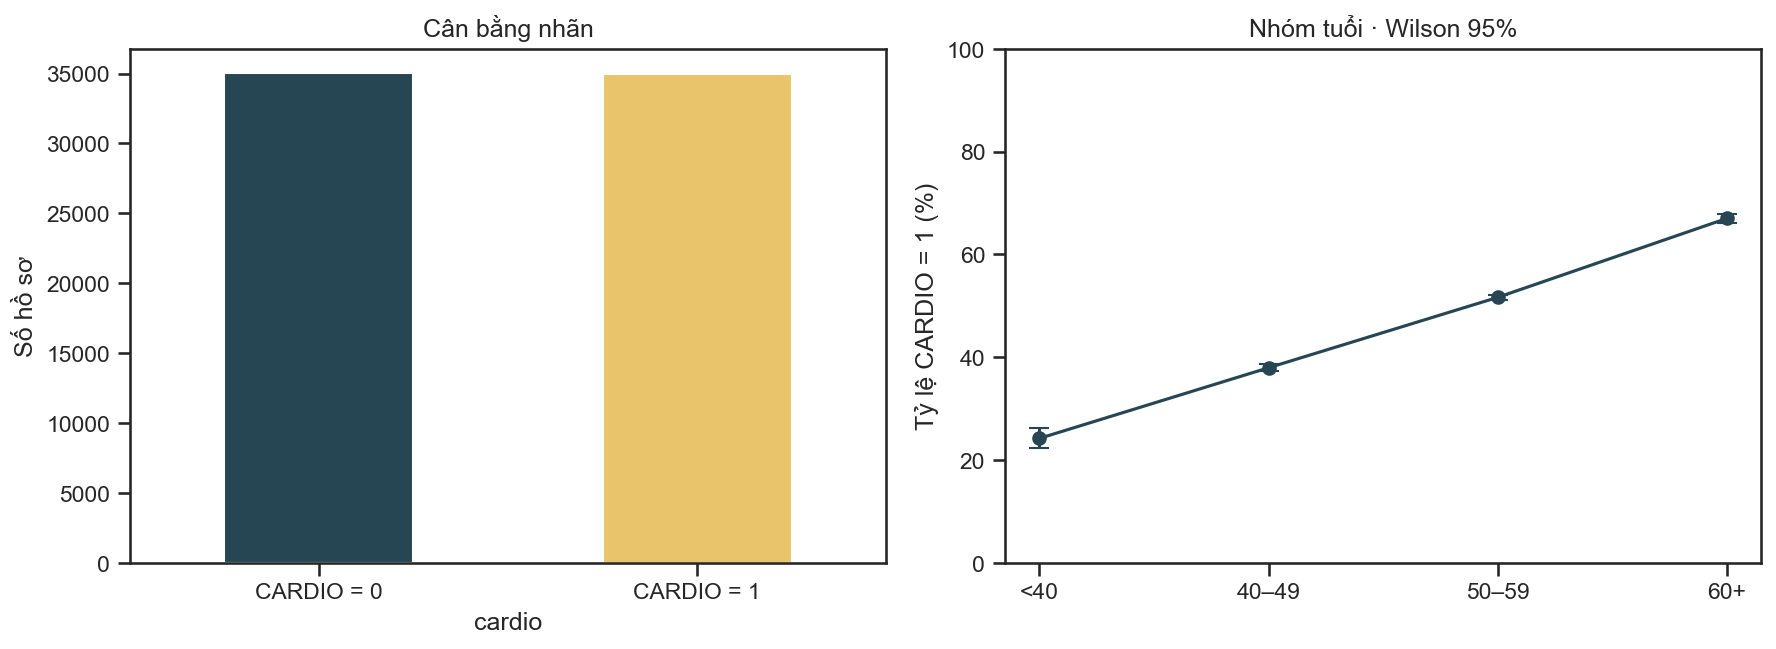

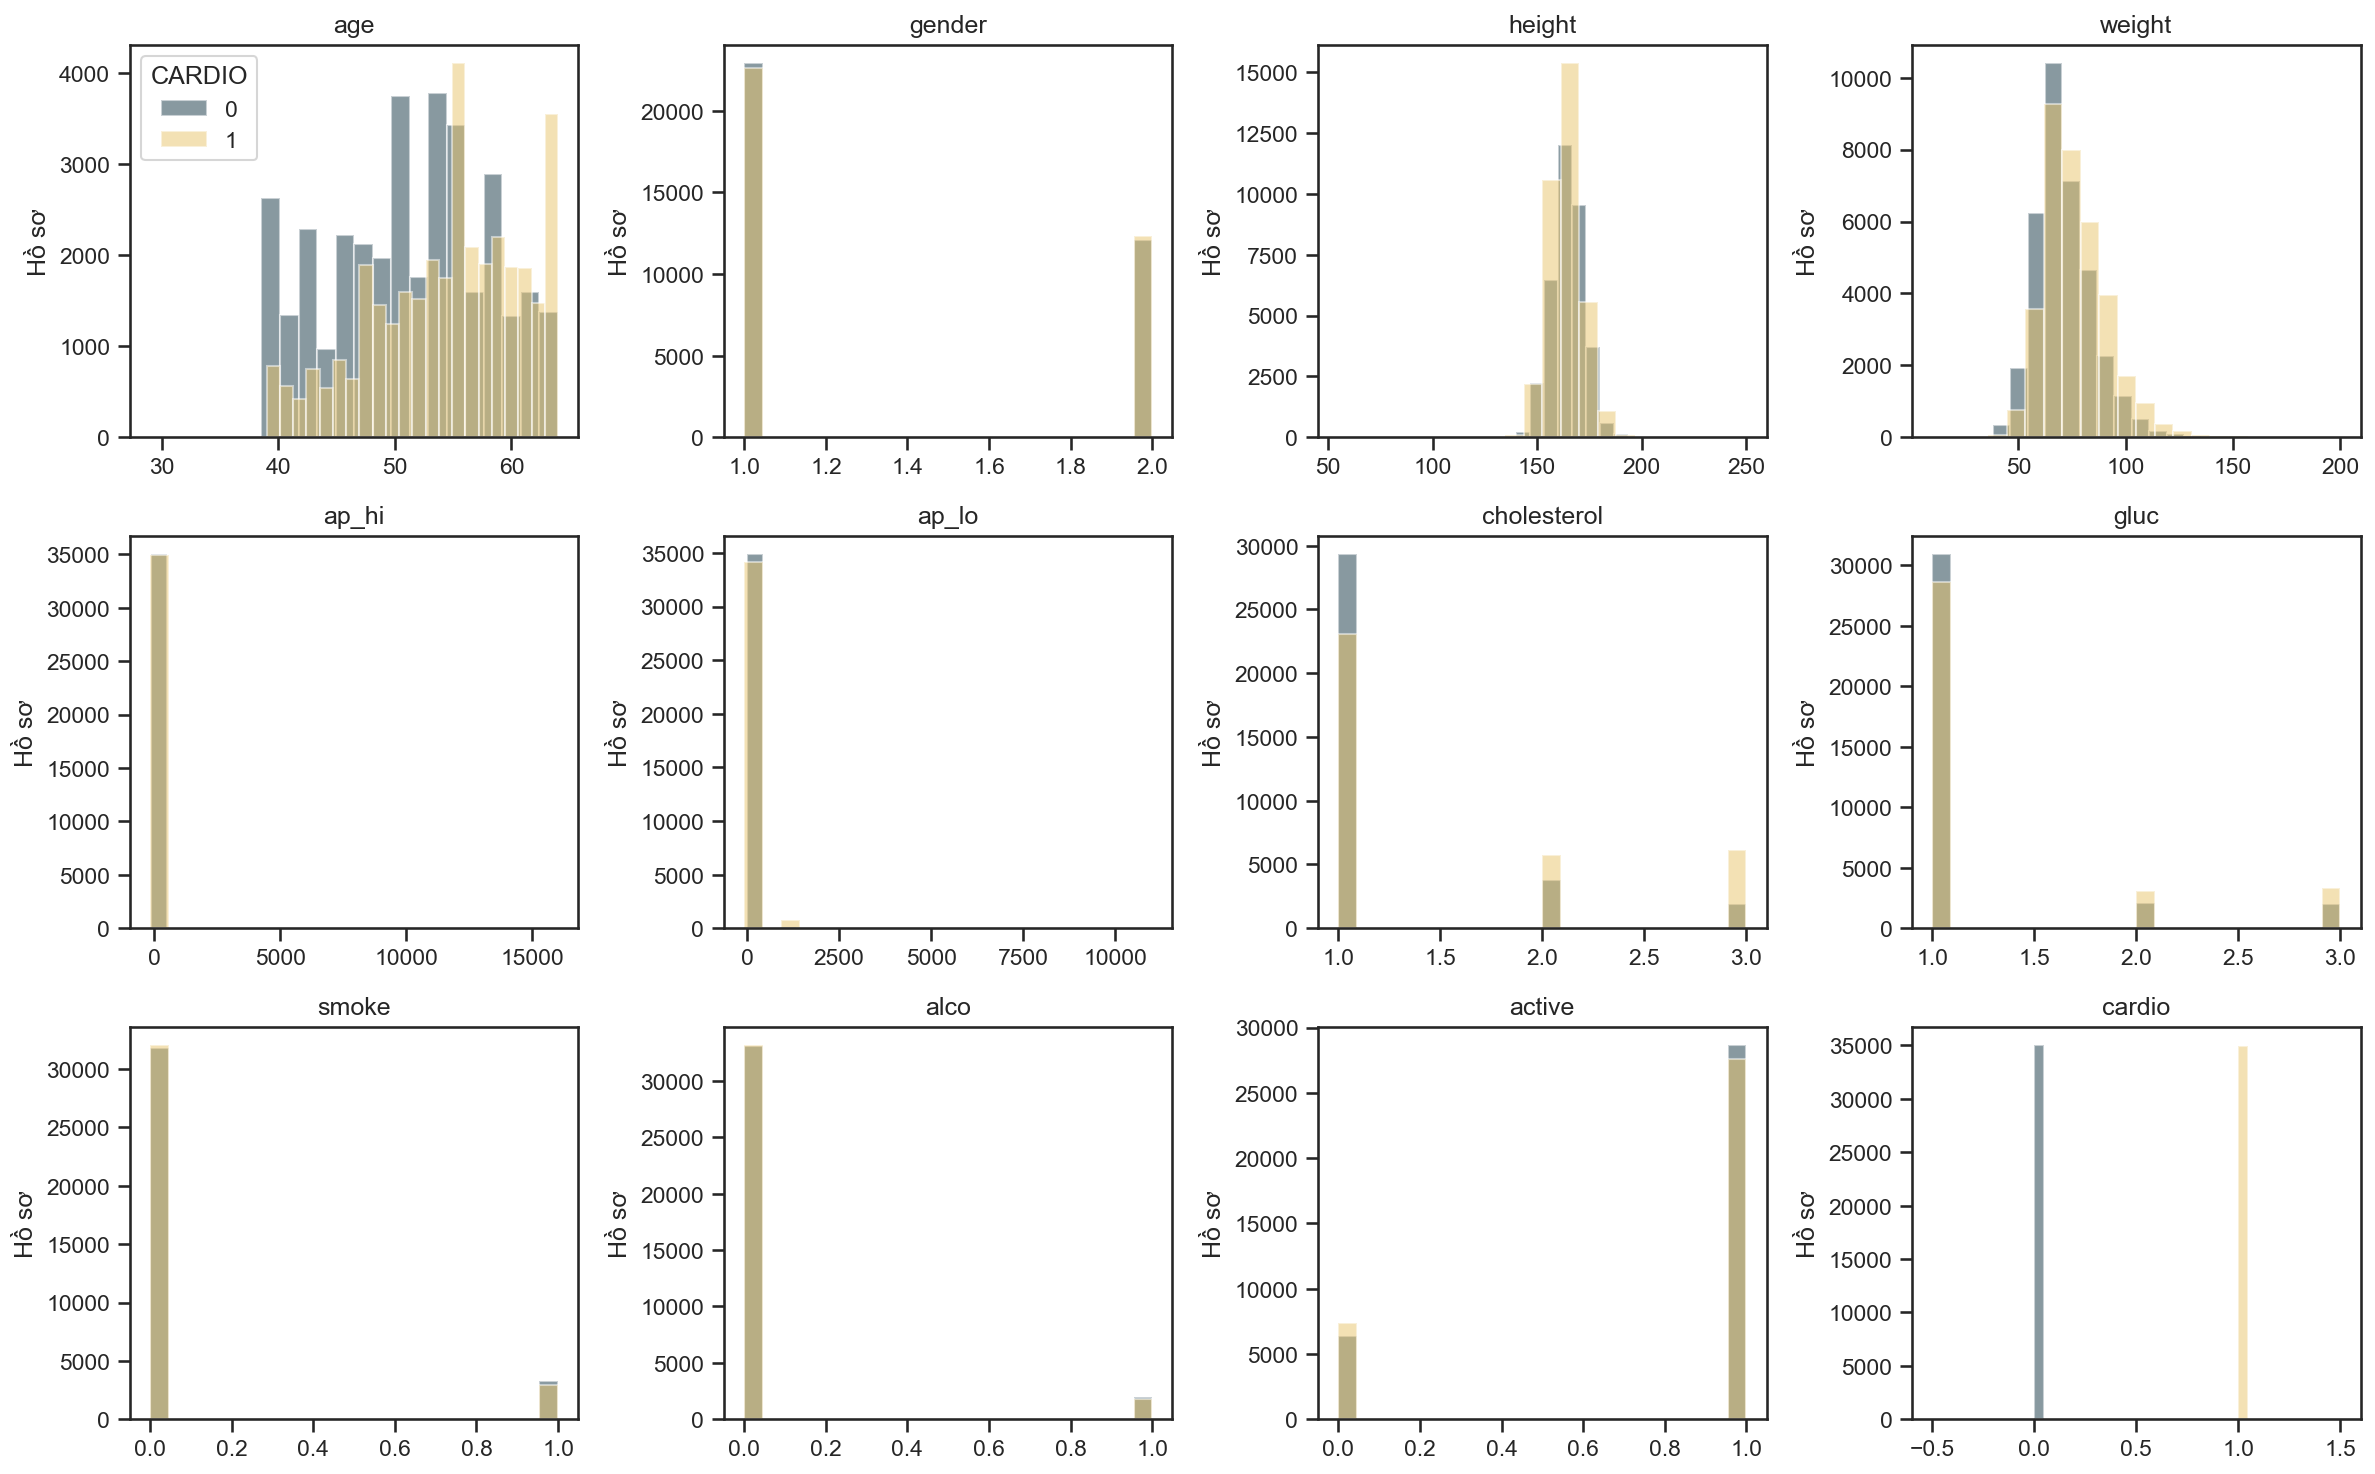

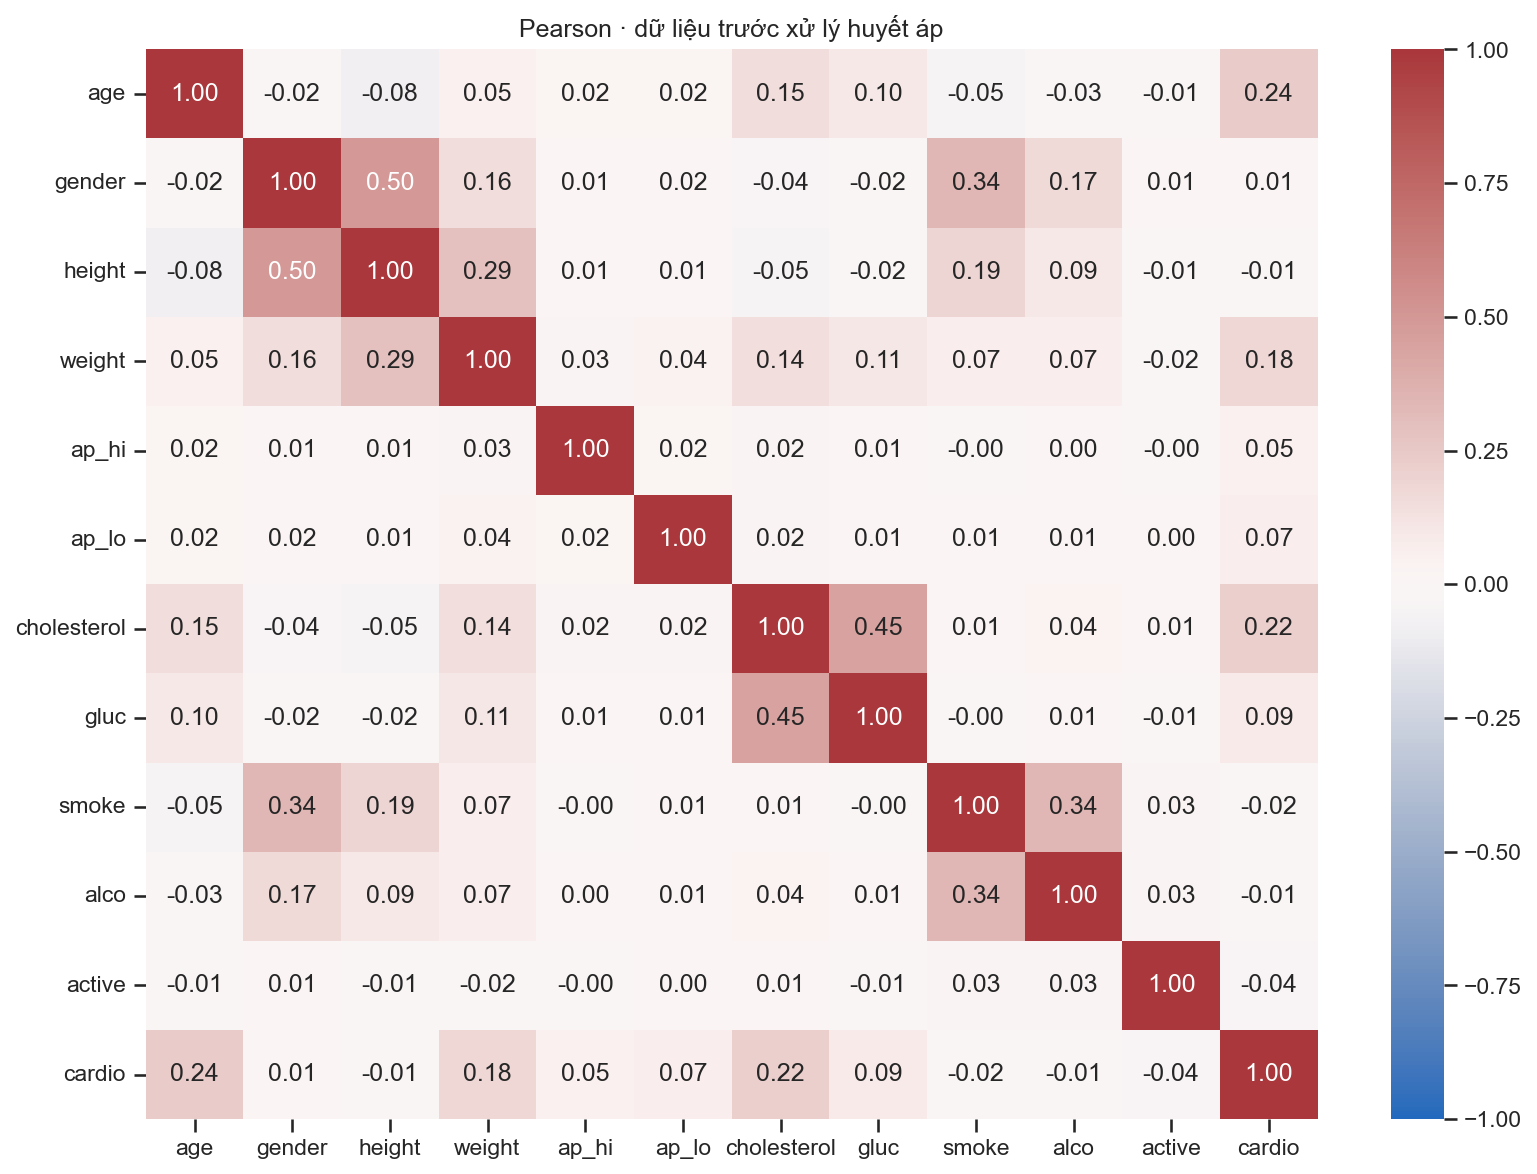

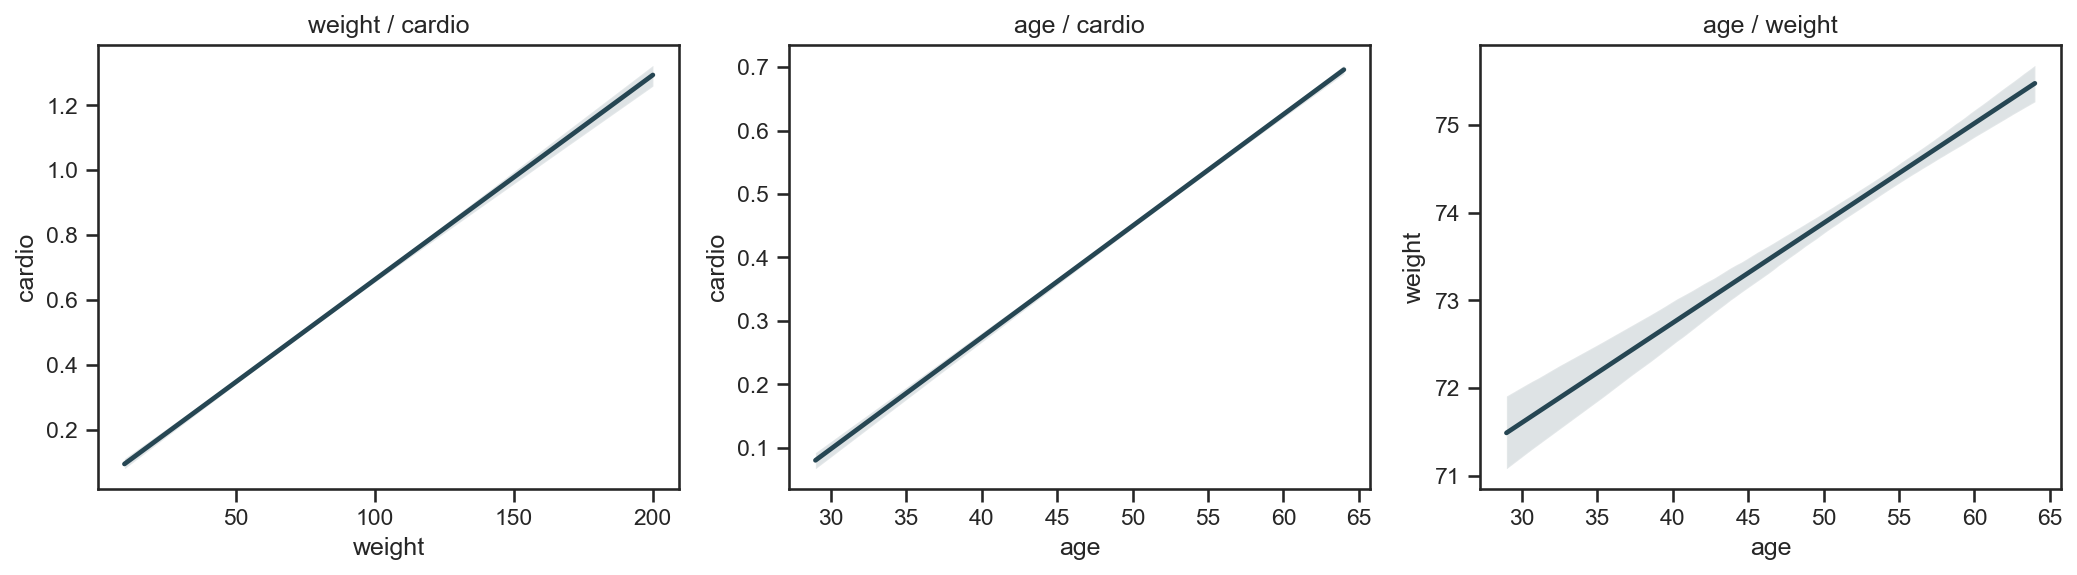

In [2]:
fig,axs=plt.subplots(1,2,figsize=(12,4.5))
df.cardio.value_counts().sort_index().plot.bar(ax=axs[0],color=['#264653','#e9c46a'])
axs[0].set_xticklabels(['CARDIO = 0','CARDIO = 1'],rotation=0); axs[0].set_ylabel('Số hồ sơ')
axs[0].set_title('Cân bằng nhãn')
age_groups=pd.cut(df.age,bins=[0,40,50,60,100],right=False,labels=['<40','40–49','50–59','60+'])
age_table=df.groupby(age_groups,observed=True).cardio.agg(['size','sum','mean']).reset_index().rename(columns={'age':'age_group','size':'records','sum':'cases','mean':'rate'})
age_table['lower'],age_table['upper']=proportion_confint(age_table.cases,age_table.records,alpha=.05,method='wilson')
display(age_table); age_table.to_csv(ROOT/'results/age_group_rates.csv',index=False)
axs[1].errorbar(range(len(age_table)),100*age_table.rate,
    yerr=np.vstack([100*(age_table.rate-age_table.lower),100*(age_table.upper-age_table.rate)]),fmt='o-',capsize=5,color='#264653')
axs[1].set_xticks(range(len(age_table)),age_table.age_group); axs[1].set_ylim(0,100)
axs[1].set_ylabel('Tỷ lệ CARDIO = 1 (%)'); axs[1].set_title('Nhóm tuổi · Wilson 95%')
figure('01_age_profile.png')
fig,axs=plt.subplots(3,4,figsize=(16,10))
for ax,col in zip(axs.flat,features+['cardio']):
    ax.hist(df.loc[df.cardio==0,col],bins=22,alpha=.55,label='0',color='#264653')
    ax.hist(df.loc[df.cardio==1,col],bins=22,alpha=.5,label='1',color='#e9c46a')
    ax.set_title(col); ax.set_ylabel('Hồ sơ')
axs.flat[0].legend(title='CARDIO'); figure('02_distributions_by_label.png')
plt.figure(figsize=(11,8)); sns.heatmap(df[features+['cardio']].corr(),annot=True,fmt='.2f',cmap='vlag',vmin=-1,vmax=1)
plt.title('Pearson · dữ liệu trước xử lý huyết áp'); figure('03_raw_correlation.png')
fig,axs=plt.subplots(1,3,figsize=(14,4))
for ax,(x,y) in zip(axs,[('weight','cardio'),('age','cardio'),('age','weight')]):
    sns.regplot(data=df,x=x,y=y,ax=ax,scatter=False,color='#264653'); ax.set_title(f'{x} / {y}')
figure('04_relationships.png')

## 3. Kiểm soát ngoại lệ huyết áp
Chặn AP_HI/AP_LO bằng Q1 − 1,5×IQR và Q3 + 1,5×IQR theo đề.
Bảng EDA dùng toàn bộ dữ liệu; pipeline mô hình ước lượng lại cận trong từng fold train.

,column,q1,q3,iqr,lower,upper,modified_rows
0,ap_hi,120.0,140.0,20.0,90.0,170.0,1435
1,ap_lo,80.0,90.0,10.0,65.0,105.0,4632


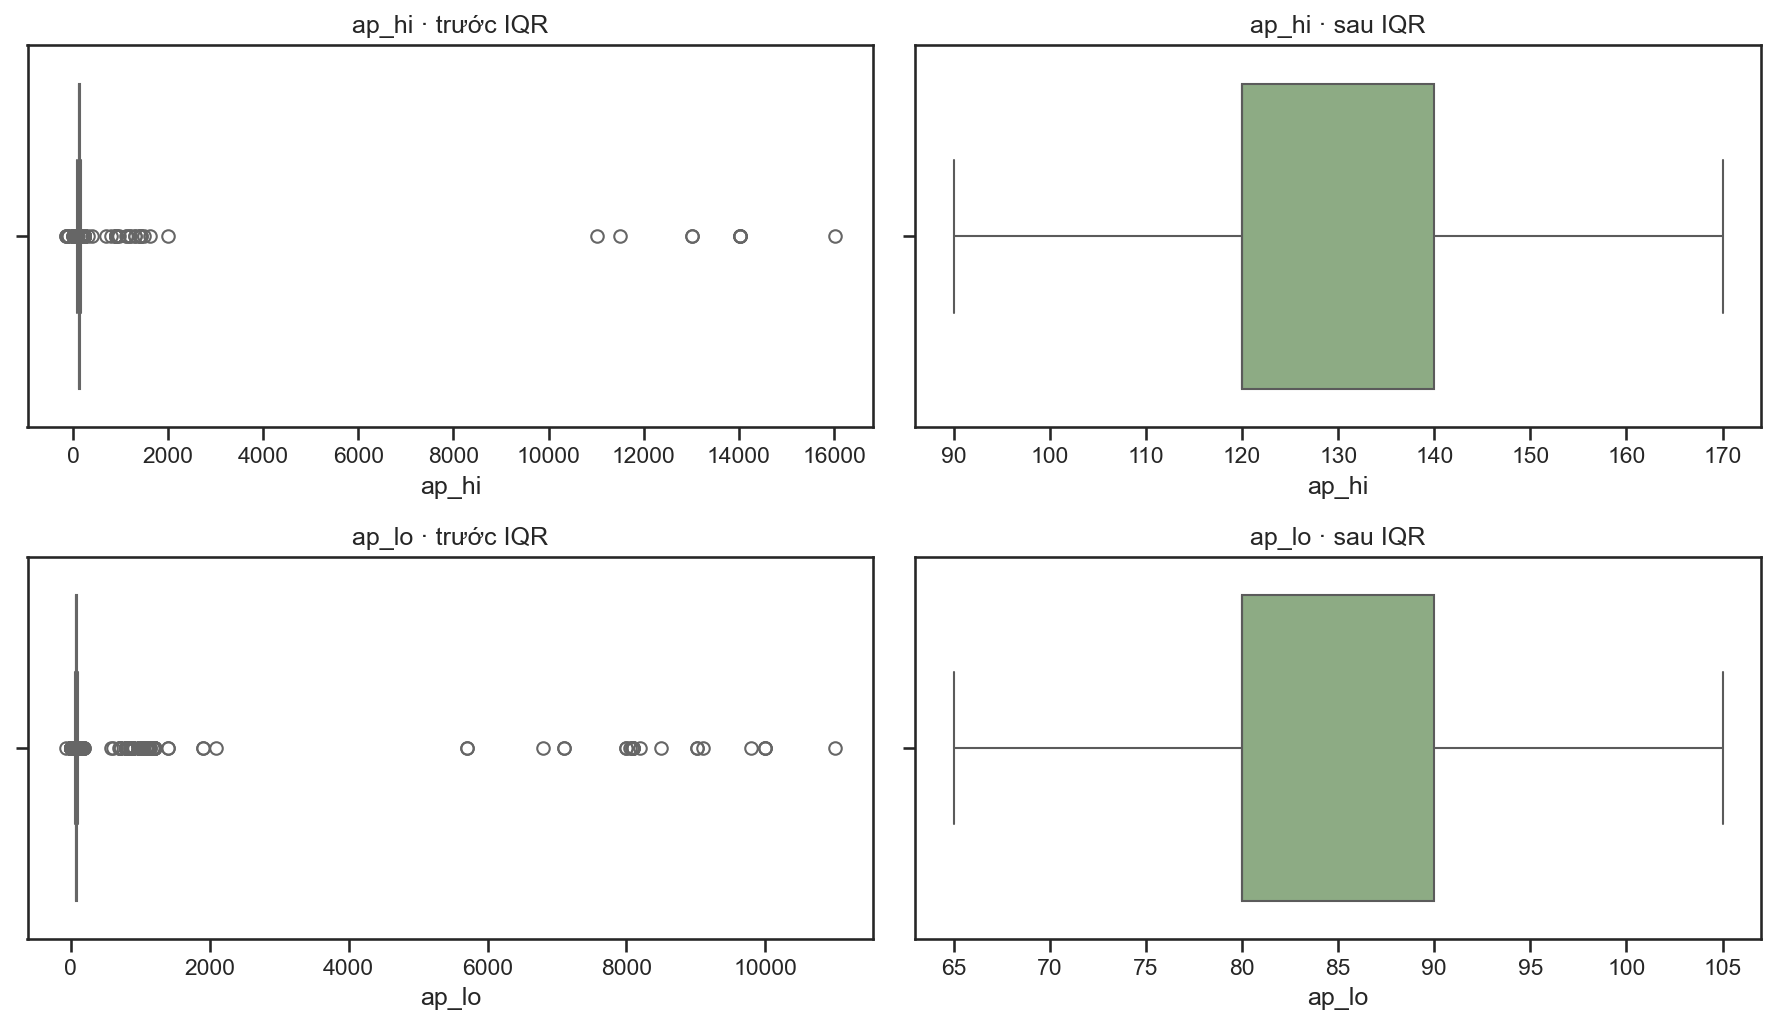

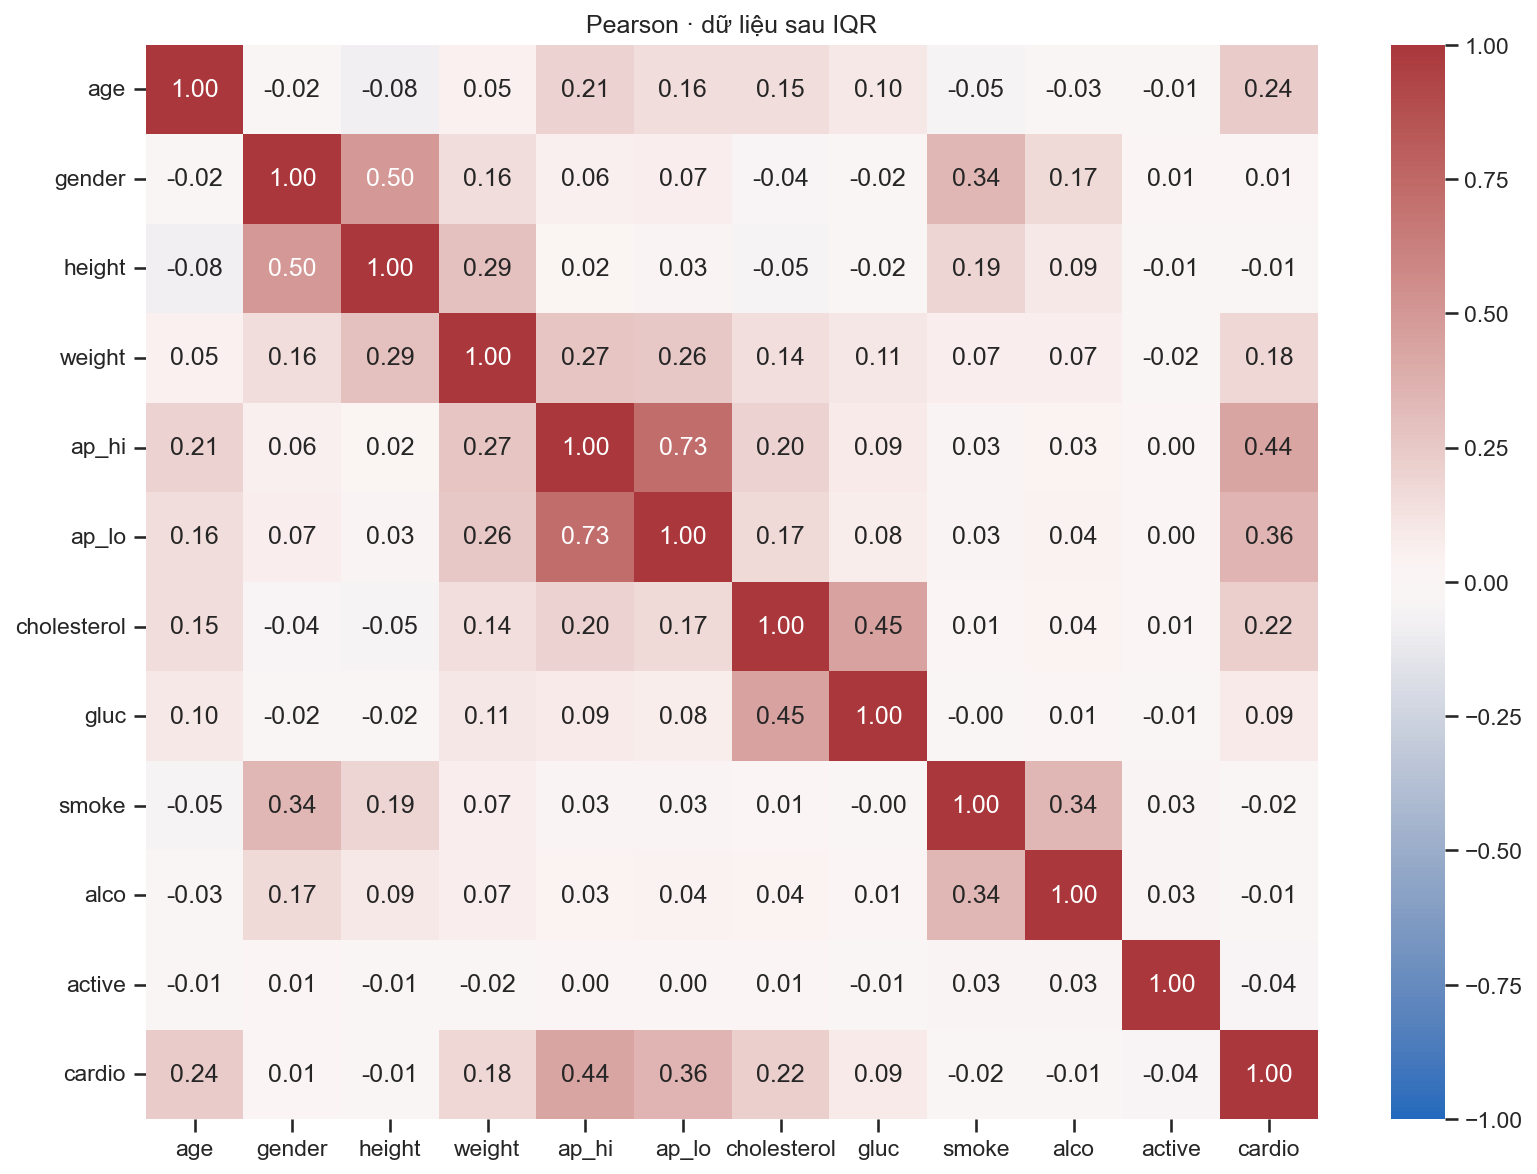

In [3]:
clean=df.copy(); bounds=[]
for col in ['ap_hi','ap_lo']:
    q1,q3=df[col].quantile([.25,.75]); iqr=q3-q1; lo=q1-1.5*iqr; hi=q3+1.5*iqr
    bounds.append({'column':col,'q1':q1,'q3':q3,'iqr':iqr,'lower':lo,'upper':hi,
                   'modified_rows':int(((df[col]<lo)|(df[col]>hi)).sum())})
    clean[col]=df[col].clip(lo,hi)
limits=pd.DataFrame(bounds); display(limits); limits.to_csv(ROOT/'results/iqr_limits.csv',index=False)
clean.to_csv(ROOT/'data/cardio_train_clean.csv',index=False)
fig,axs=plt.subplots(2,2,figsize=(12,7))
for i,col in enumerate(['ap_hi','ap_lo']):
    sns.boxplot(x=df[col],ax=axs[i,0],color='#e9c46a'); axs[i,0].set_title(f'{col} · trước IQR')
    sns.boxplot(x=clean[col],ax=axs[i,1],color='#8ab17d'); axs[i,1].set_title(f'{col} · sau IQR')
figure('05_pressure_audit.png')
plt.figure(figsize=(11,8)); sns.heatmap(clean[features+['cardio']].corr(),annot=True,fmt='.2f',cmap='vlag',vmin=-1,vmax=1)
plt.title('Pearson · dữ liệu sau IQR'); figure('06_clean_correlation.png')

## 4. Kiểm định thống kê và hồi quy theo đề
α = 0,05. ANOVA cho cholesterol, T-test cho hai nhóm tuổi, Pearson cho cân nặng, Chi-square cho ALCO;
Chi-square cholesterol bổ sung đối chiếu. OLS dùng để tái hiện yêu cầu thống kê, không dùng làm bộ phân loại cuối.

In [4]:
tests=[]
f,p=stats.f_oneway(*(clean.loc[clean.cholesterol==k,'cardio'] for k in [1,2,3]))
tests.append(['ANOVA: cholesterol vs cardio',float(f),float(p)])
low=clean.loc[clean.age<clean.age.mean(),'cardio']; high=clean.loc[clean.age>=clean.age.mean(),'cardio']
lev,lev_p=stats.levene(low,high,center='mean')
t,p=stats.ttest_ind(low,high,equal_var=lev_p>.05)
tests.append(['T-test: hai nhóm tuổi',float(t),float(p)])
r,p=stats.pearsonr(clean.weight,clean.cardio)
tests.append(['Pearson: weight vs cardio',float(r),float(p)])
chi,p,dof,expected=stats.chi2_contingency(pd.crosstab(clean.alco,clean.cardio),correction=True)
tests.append(['Chi-square: alco vs cardio',float(chi),float(p)])
chi,p,_,_=stats.chi2_contingency(pd.crosstab(clean.cholesterol,clean.cardio))
tests.append(['Chi-square bổ sung: cholesterol',float(chi),float(p)])
tests=pd.DataFrame(tests,columns=['test','statistic','p_value'])
tests['conclusion']=np.where(tests.p_value<.05,'Bác bỏ H0','Chưa đủ bằng chứng bác bỏ H0')
display(tests)
print(f'Levene: statistic={lev:.6g}; p={lev_p:.6g}; equal_var={lev_p>.05}')
print(f'Tỷ lệ bệnh nhóm tuổi thấp: {low.mean():.2%}; nhóm tuổi cao: {high.mean():.2%}')
tests.to_csv(ROOT/'results/statistical_tests.csv',index=False)
ols=sm.OLS(clean.cardio,sm.add_constant(clean[features].astype(float))).fit()
print(ols.summary())
(ROOT/'results/ols_summary.txt').write_text(ols.summary().as_text(),encoding='utf-8')
ols_table=pd.DataFrame({'feature':ols.params.index,'coefficient':ols.params.values,'p_value':ols.pvalues.values})
ols_table.to_csv(ROOT/'results/ols_coefficients.csv',index=False)

Levene: statistic=133.983; p=5.88007e-31; equal_var=False
Tỷ lệ bệnh nhóm tuổi thấp: 39.15%; nhóm tuổi cao: 58.71%
                            OLS Regression Results                            
Dep. Variable:                 cardio   R-squared:                       0.235
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     1954.
Date:                Tue, 06 Oct 2026   Prob (F-statistic):               0.00
Time:                        16:44:14   Log-Likelihood:                -41431.
No. Observations:               70000   AIC:                         8.289e+04
Df Residuals:                   69988   BIC:                         8.300e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
---------------

,test,statistic,p_value,conclusion
0,ANOVA: cholesterol vs cardio,1799.660786,0.000000,Bác bỏ H0
1,T-test: hai nhóm tuổi,-52.513509,0.000000,Bác bỏ H0
2,Pearson: weight vs cardio,0.181660,0.000000,Bác bỏ H0
3,Chi-square: alco vs cardio,3.696547,0.054525,Chưa đủ bằng chứng bác bỏ H0
4,Chi-square bổ sung: cholesterol,3423.438898,0.000000,Bác bỏ H0


## 5. Chọn tham số trên tập huấn luyện
70% train / 30% test, phân tầng CARDIO, seed 2026. Chọn Random Forest bằng F1 trung bình của 5 fold.
Lưới 4 cấu hình: max_depth ∈ {10,16}, min_samples_leaf ∈ {4,12}, n_estimators = 200.
Accuracy vẫn được báo cáo theo đề. F1 là tiêu chí chọn trong phiên bản này để xét đồng thời precision và recall.
Test không tham gia tính cận IQR, chuẩn hóa hay lựa chọn tham số. Không điều chỉnh ngưỡng sau khi xem test.

In [5]:
X=df[features]; y=df.cardio
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,random_state=SEED,stratify=y)
train_ids=raw.loc[X_train.index,'id']; test_ids=raw.loc[X_test.index,'id']
assert len(X_train)==49000 and len(X_test)==21000 and set(train_ids).isdisjoint(set(test_ids))
pd.DataFrame({'id':train_ids,'split':'train'}).to_csv(ROOT/'results/train_ids.csv',index=False)
pd.DataFrame({'id':test_ids,'split':'test'}).to_csv(ROOT/'results/test_ids.csv',index=False)
def pipeline(model):
    return Pipeline([('iqr',IQRClipper(columns=(4,5))),
        ('scale',ColumnTransformer([('numeric',StandardScaler(),[0,2,3,4,5]),
            ('categorical','passthrough',[1,6,7,8,9,10])])),('model',model)])
search=GridSearchCV(pipeline(RandomForestClassifier(n_estimators=200,random_state=SEED,n_jobs=1)),
    {'model__max_depth':[10,16],'model__min_samples_leaf':[4,12]},
    scoring={'f1':'f1','accuracy':'accuracy','roc_auc':'roc_auc'},refit='f1',
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED),n_jobs=1)
search.fit(X_train,y_train)
cv_table=pd.DataFrame(search.cv_results_)[['params','mean_test_f1','std_test_f1','rank_test_f1','mean_test_accuracy','mean_test_roc_auc']].sort_values('rank_test_f1')
display(cv_table); cv_table.to_csv(ROOT/'results/grid_search.csv',index=False)
print('Tham số chọn:',search.best_params_,'; F1 CV:',search.best_score_)

Tham số chọn: {'model__max_depth': 16, 'model__min_samples_leaf': 12} ; F1 CV: 0.7227417916717978


,params,mean_test_f1,std_test_f1,rank_test_f1,mean_test_accuracy,mean_test_roc_auc
3,"{'model__max_depth': 16, 'model__min_samples_l...",0.722742,0.004823,1,0.734551,0.801362
2,"{'model__max_depth': 16, 'model__min_samples_l...",0.721691,0.005044,2,0.733592,0.799730
1,"{'model__max_depth': 10, 'model__min_samples_l...",0.719393,0.005058,3,0.734755,0.801953
0,"{'model__max_depth': 10, 'model__min_samples_l...",0.719226,0.004225,4,0.735143,0.802039


Dummy baseline 0.5003 0.0
RidgeClassifier 0.7262 0.708
RandomForest 0.7079 0.7071
GradientBoosting 0.7353 0.725
AdaBoost 0.7302 0.7099
Bagging KNN 0.722 0.7101
ExtraTrees 0.6946 0.6939
Stacking 0.7307 0.7239
RandomForest tuned (F1 CV) 0.7343 0.7232


,model,accuracy,precision,recall,f1,roc_auc,balanced_accuracy,average_precision,fit_evaluate_seconds
3,GradientBoosting,0.735286,0.753936,0.698113,0.724952,0.801996,0.735264,0.781030,3.324749
7,Stacking,0.730714,0.742265,0.706404,0.723890,0.794987,0.730700,0.774494,14.592784
8,RandomForest tuned (F1 CV),0.734286,0.754295,0.694492,0.723159,0.800964,0.734263,0.784092,1.013575
5,Bagging KNN,0.722048,0.741571,0.681151,0.710078,0.780883,0.722024,0.760312,7.230756
4,AdaBoost,0.730190,0.767094,0.660663,0.709912,0.795521,0.730151,0.771299,2.029833
1,RidgeClassifier,0.726238,0.758133,0.663998,0.707950,0.791044,0.726203,0.770066,0.053102
2,RandomForest,0.707905,0.708612,0.705641,0.707124,0.764433,0.707903,0.743870,5.925927
6,ExtraTrees,0.694619,0.695132,0.692682,0.693905,0.740402,0.694618,0.691820,6.432716
0,Dummy baseline,0.500286,0.000000,0.000000,0.000000,0.500000,0.500000,0.499714,0.020974


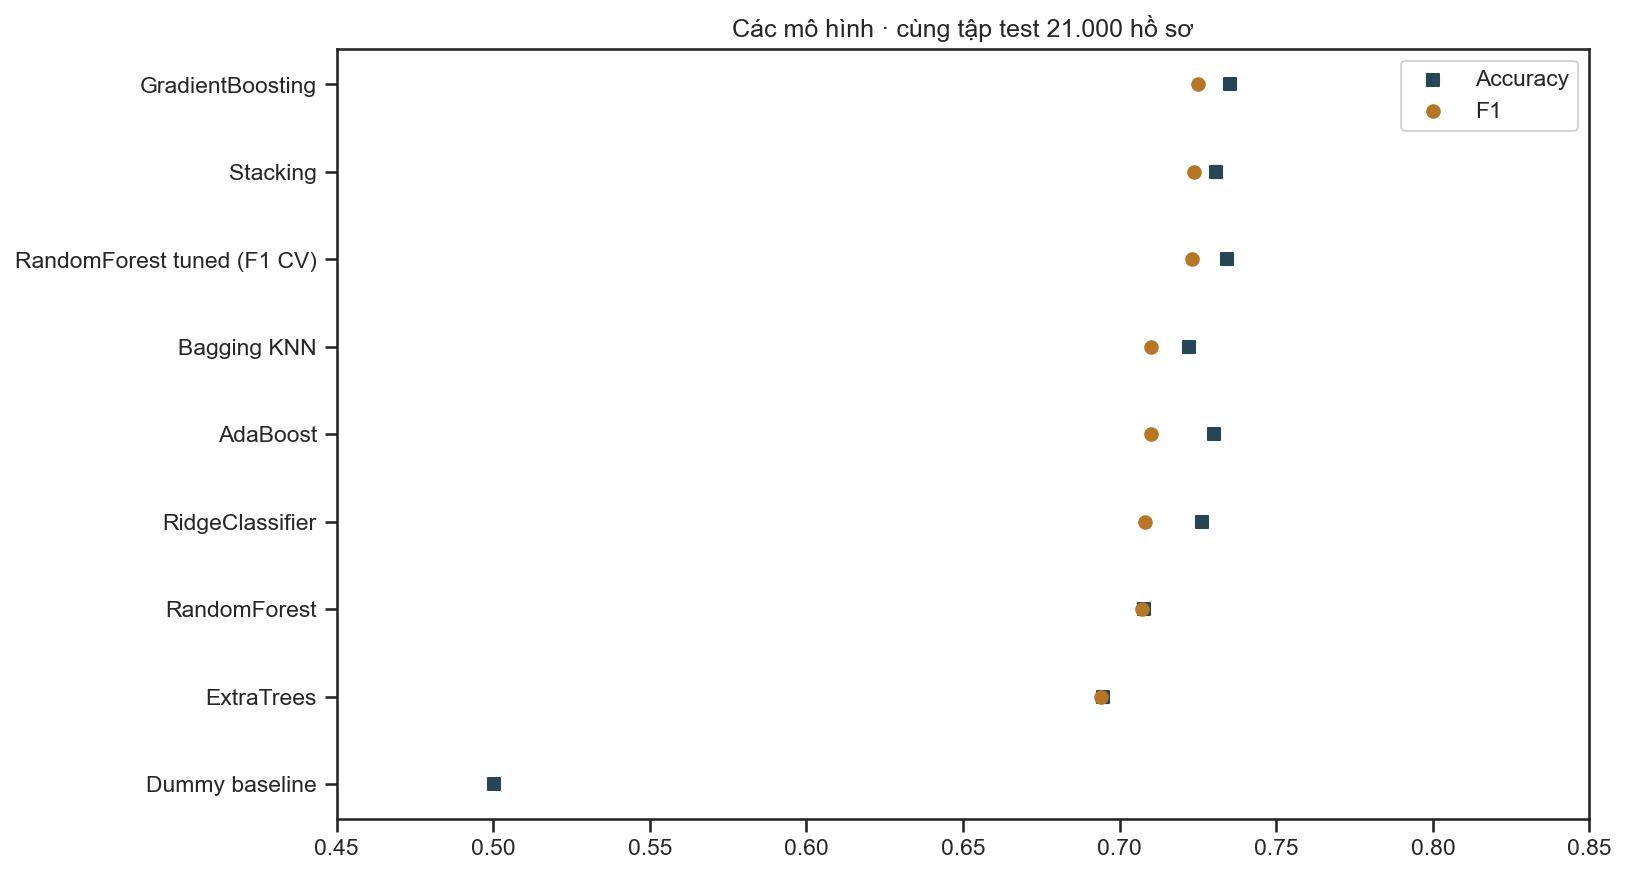

In [6]:
stacking=StackingClassifier(estimators=[('ridge',pipeline(RidgeClassifier())),
    ('knn',pipeline(KNeighborsClassifier(n_neighbors=20,metric='euclidean')))],
    final_estimator=GradientBoostingClassifier(n_estimators=25,subsample=.5,min_samples_leaf=25,max_features=1,random_state=SEED),
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED),n_jobs=1)
models={
    'Dummy baseline':DummyClassifier(strategy='most_frequent'),
    'RidgeClassifier':pipeline(RidgeClassifier(alpha=.0001)),
    'RandomForest':pipeline(RandomForestClassifier(n_estimators=100,random_state=SEED,n_jobs=1)),
    'GradientBoosting':pipeline(GradientBoostingClassifier(random_state=SEED)),
    'AdaBoost':pipeline(AdaBoostClassifier(n_estimators=100,random_state=SEED)),
    'Bagging KNN':pipeline(BaggingClassifier(estimator=KNeighborsClassifier(),max_samples=.5,max_features=.5,random_state=SEED,n_jobs=1)),
    'ExtraTrees':pipeline(ExtraTreesClassifier(n_estimators=100,random_state=SEED,n_jobs=1)),
    'Stacking':stacking,'RandomForest tuned (F1 CV)':search.best_estimator_}
records=[]; predictions={}
for name,model in models.items():
    start=time.perf_counter()
    if name!='RandomForest tuned (F1 CV)': model.fit(X_train,y_train)
    pred=model.predict(X_test); predictions[name]=pred
    score=model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test)
    records.append({'model':name,'accuracy':accuracy_score(y_test,pred),'precision':precision_score(y_test,pred,zero_division=0),
        'recall':recall_score(y_test,pred,zero_division=0),'f1':f1_score(y_test,pred,zero_division=0),
        'roc_auc':roc_auc_score(y_test,score),'balanced_accuracy':balanced_accuracy_score(y_test,pred),
        'average_precision':average_precision_score(y_test,score),'fit_evaluate_seconds':time.perf_counter()-start})
    print(name,round(records[-1]['accuracy'],4),round(records[-1]['f1'],4),flush=True)
metrics=pd.DataFrame(records).sort_values('f1',ascending=False); display(metrics)
metrics.to_csv(ROOT/'results/model_comparison.csv',index=False)
fig,ax=plt.subplots(figsize=(11,6)); order=list(range(len(metrics)))
ax.scatter(metrics.accuracy,order,label='Accuracy',marker='s',color='#264653')
ax.scatter(metrics.f1,order,label='F1',marker='o',color='#b57625')
ax.set_yticks(order,metrics.model); ax.invert_yaxis(); ax.set_xlim(.45,.85)
ax.set_title('Các mô hình · cùng tập test 21.000 hồ sơ'); ax.legend(); figure('07_accuracy_f1.png')

## 6. Đánh giá sai số của mô hình đã chọn
Random Forest đã tinh chỉnh là mô hình được chọn trước khi đánh giá test; bảng test không thay đổi lựa chọn này.
Các biểu đồ ROC, precision–recall và reliability bổ sung góc nhìn ngoài Accuracy.
Reliability chỉ là đánh giá xác suất đầu ra, không có bước hiệu chỉnh xác suất được huấn luyện thêm.

              precision    recall  f1-score   support

           0     0.7172    0.7740    0.7446     10506
           1     0.7543    0.6945    0.7232     10494

    accuracy                         0.7343     21000
   macro avg     0.7358    0.7343    0.7339     21000
weighted avg     0.7358    0.7343    0.7339     21000



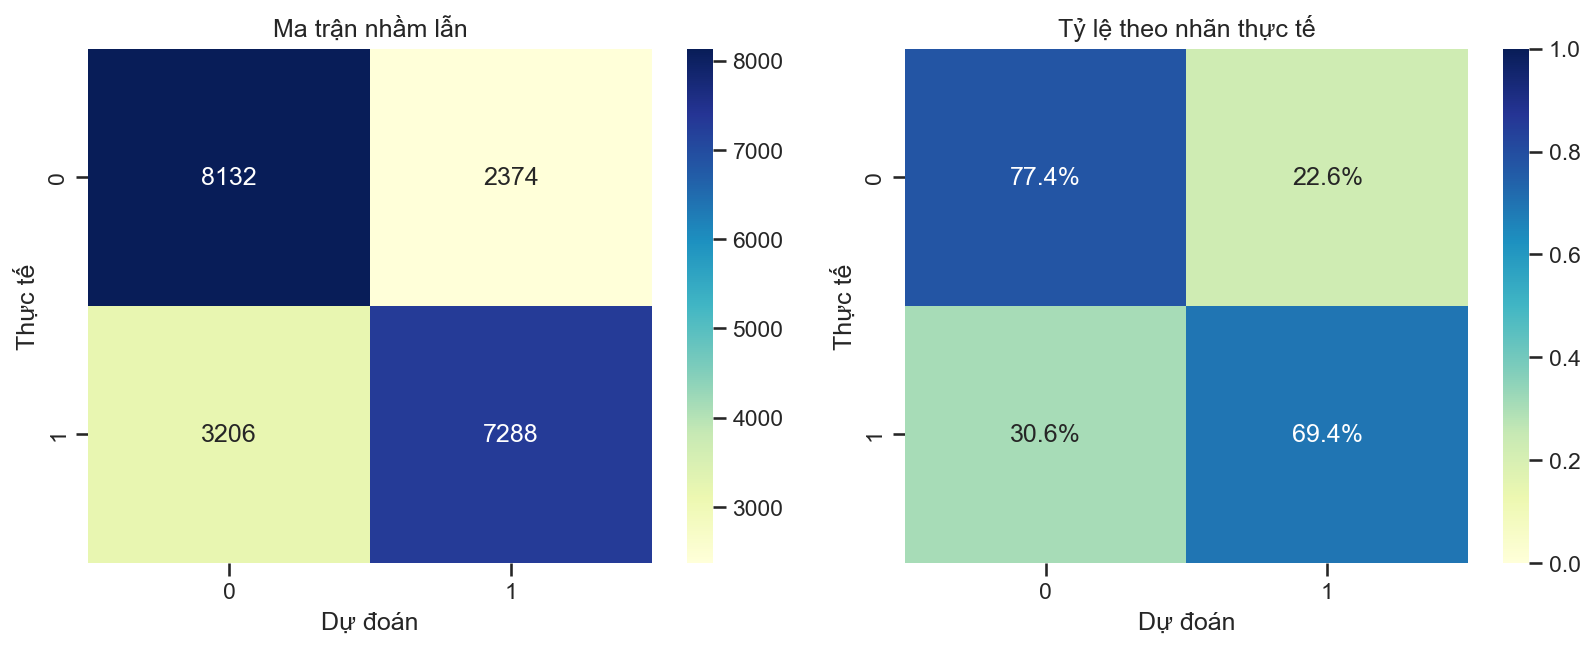

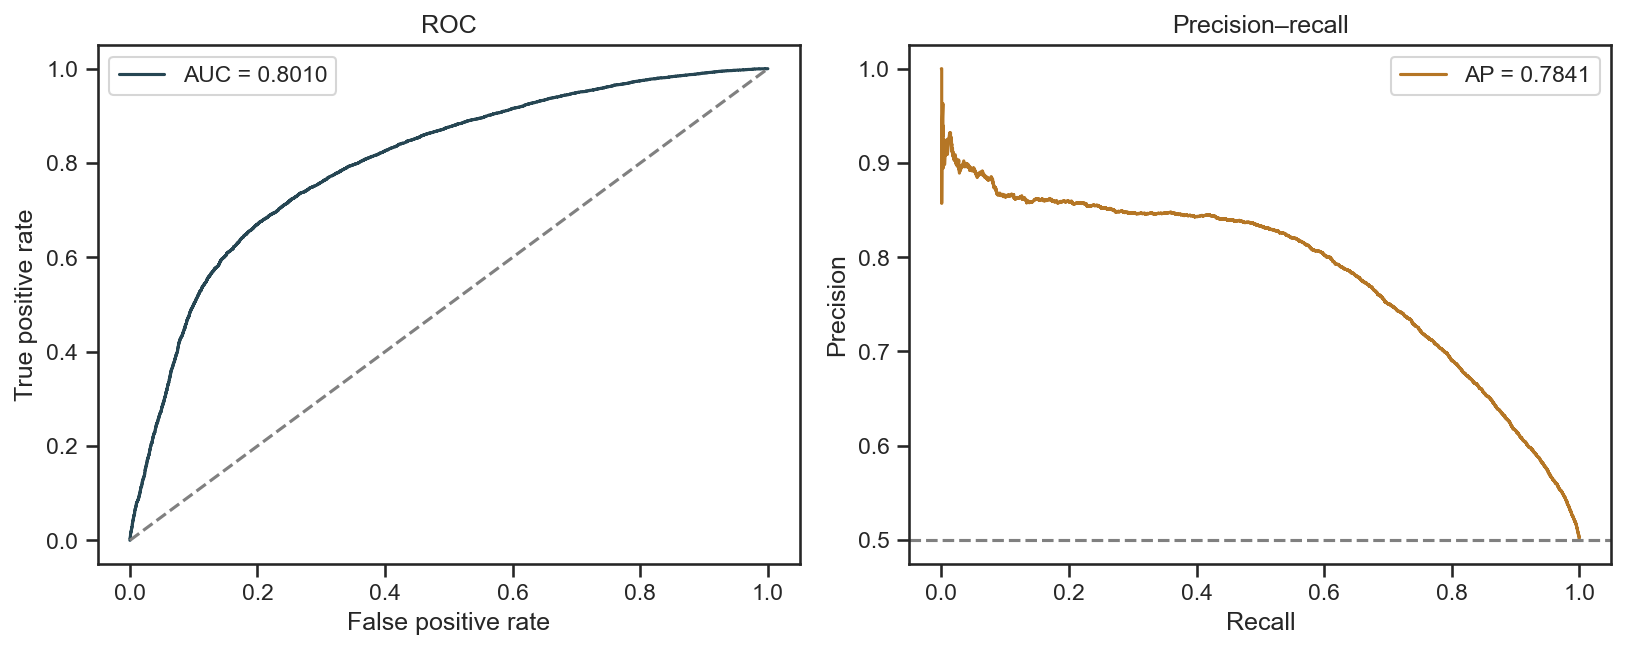

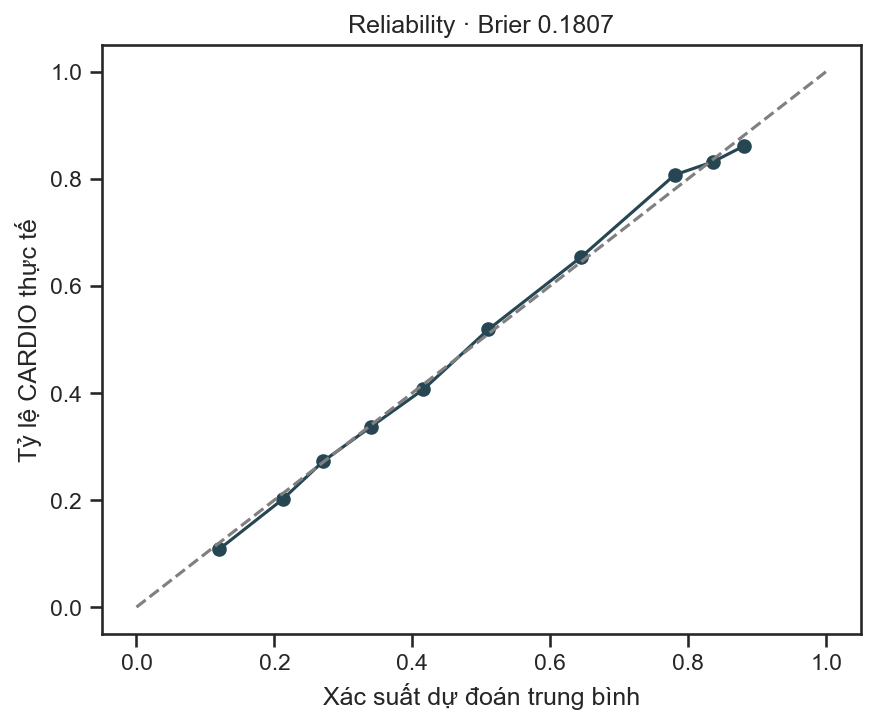

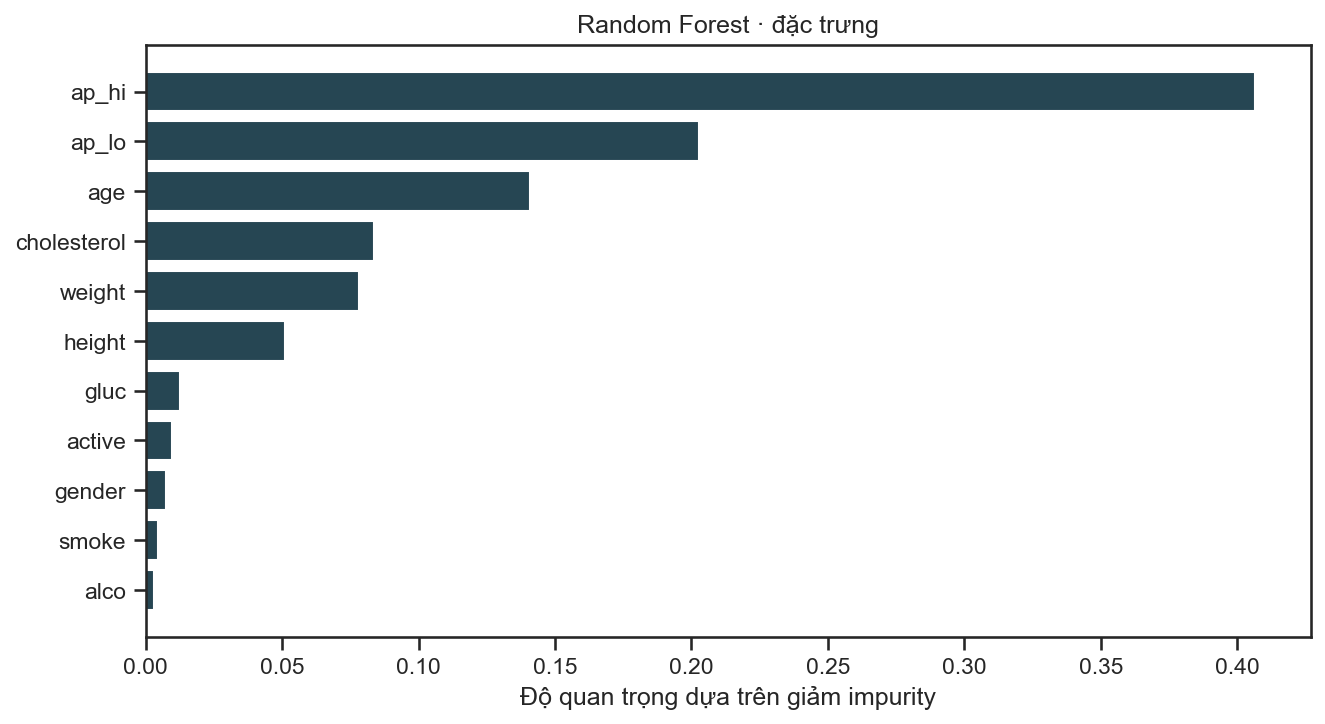

,gender,records,actual_cases,accuracy,recall,precision,false_negative_rate,false_positive_rate
0,1,13630,6770,0.738518,0.696160,0.757717,0.303840,0.219679
1,2,7370,3724,0.726459,0.691461,0.748112,0.308539,0.237795


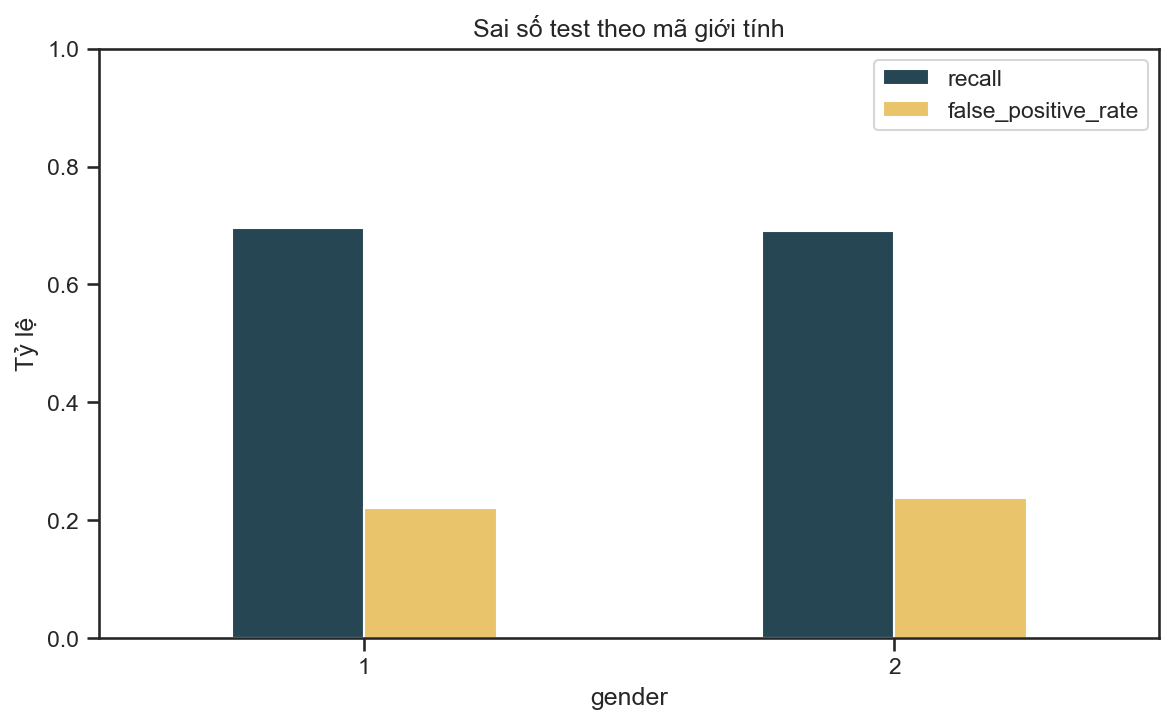

In [7]:
selected='RandomForest tuned (F1 CV)'; final_model=models[selected]; pred=predictions[selected]
proba=final_model.predict_proba(X_test)[:,1]; cm=confusion_matrix(y_test,pred)
print(classification_report(y_test,pred,digits=4))
fig,axs=plt.subplots(1,2,figsize=(11,4.5))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlGnBu',ax=axs[0],xticklabels=['0','1'],yticklabels=['0','1'])
axs[0].set_xlabel('Dự đoán'); axs[0].set_ylabel('Thực tế'); axs[0].set_title('Ma trận nhầm lẫn')
row_cm=cm/cm.sum(axis=1,keepdims=True)
sns.heatmap(row_cm,annot=True,fmt='.1%',cmap='YlGnBu',vmin=0,vmax=1,ax=axs[1])
axs[1].set_xlabel('Dự đoán'); axs[1].set_ylabel('Thực tế'); axs[1].set_title('Tỷ lệ theo nhãn thực tế')
figure('08_errors.png')
fpr,tpr,_=roc_curve(y_test,proba); precision,recall,_=precision_recall_curve(y_test,proba)
fig,axs=plt.subplots(1,2,figsize=(11,4.5))
axs[0].plot(fpr,tpr,color='#264653',label=f'AUC = {roc_auc_score(y_test,proba):.4f}')
axs[0].plot([0,1],[0,1],'--',color='gray'); axs[0].set(xlabel='False positive rate',ylabel='True positive rate',title='ROC'); axs[0].legend()
axs[1].plot(recall,precision,color='#b57625',label=f'AP = {average_precision_score(y_test,proba):.4f}')
axs[1].axhline(y_test.mean(),ls='--',color='gray'); axs[1].set(xlabel='Recall',ylabel='Precision',title='Precision–recall'); axs[1].legend()
figure('09_roc_pr.png')
frac,mean=calibration_curve(y_test,proba,n_bins=10,strategy='quantile')
pd.DataFrame({'mean_probability':mean,'observed_rate':frac}).to_csv(ROOT/'results/reliability_bins.csv',index=False)
plt.figure(figsize=(6,5)); plt.plot(mean,frac,'o-',color='#264653'); plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('Xác suất dự đoán trung bình'); plt.ylabel('Tỷ lệ CARDIO thực tế'); plt.title(f'Reliability · Brier {brier_score_loss(y_test,proba):.4f}')
figure('10_reliability.png')
names=['age','height','weight','ap_hi','ap_lo','gender','cholesterol','gluc','smoke','alco','active']
importance=pd.DataFrame({'feature':names,'importance':final_model.named_steps['model'].feature_importances_}).sort_values('importance',ascending=False)
importance.to_csv(ROOT/'results/feature_importance.csv',index=False)
plt.figure(figsize=(9,5)); plt.barh(importance.feature[::-1],importance.importance[::-1],color='#264653')
plt.xlabel('Độ quan trọng dựa trên giảm impurity'); plt.title('Random Forest · đặc trưng'); figure('11_rf_importance.png')
output=pd.DataFrame({'id':test_ids.to_numpy(),'actual':y_test.to_numpy(),'predicted':pred,'probability':proba,'gender':X_test.gender.to_numpy()})
output.to_csv(ROOT/'results/test_predictions.csv',index=False)
subgroups=[]
for gender,group in output.groupby('gender'):
    c=confusion_matrix(group.actual,group.predicted,labels=[0,1]); tn,fp,fn,tp=c.ravel()
    subgroups.append({'gender':int(gender),'records':len(group),'actual_cases':int(group.actual.sum()),
        'accuracy':accuracy_score(group.actual,group.predicted),'recall':recall_score(group.actual,group.predicted),
        'precision':precision_score(group.actual,group.predicted),'false_negative_rate':float(fn/(fn+tp)),
        'false_positive_rate':float(fp/(fp+tn))})
subgroup=pd.DataFrame(subgroups); display(subgroup); subgroup.to_csv(ROOT/'results/gender_error_rates.csv',index=False)
subgroup.set_index('gender')[['recall','false_positive_rate']].plot.bar(figsize=(8,5),color=['#264653','#e9c46a'])
plt.ylim(0,1); plt.ylabel('Tỷ lệ'); plt.xticks(rotation=0); plt.title('Sai số test theo mã giới tính'); figure('12_subgroup_errors.png')
joblib.dump(final_model,ROOT/'results/cardio_classifier.joblib',compress=3)
selected_row=metrics.set_index('model').loc[selected].to_dict()
summary={'author':'Huy Dung','variant':'HD-2026','seed':SEED,'quality':quality,'selected_model':selected,
    'selected_test_metrics':selected_row,'cv_f1':float(search.best_score_),'cv_folds':5,'selection_metric':'f1',
    'best_params':search.best_params_,'confusion_matrix':cm.tolist(),'brier_score':brier_score_loss(y_test,proba),
    'train_rows':len(X_train),'test_rows':len(X_test),'train_iqr_lower':final_model.named_steps['iqr'].lower_.tolist(),
    'train_iqr_upper':final_model.named_steps['iqr'].upper_.tolist(),'cloud_executed':False,'github_uploaded':False,
    'execution_mode':'local_with_persistent_sqlite','versions':{p:metadata.version(p) for p in ['numpy','pandas','scipy','scikit-learn','statsmodels','matplotlib','seaborn']}}
(ROOT/'results/summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
pd.DataFrame([{'package':k,'version':v} for k,v in summary['versions'].items()]).to_csv(ROOT/'results/environment_versions.csv',index=False)

## 7. Cách đọc kết quả và giới hạn
- F1 CV dùng để chọn cấu hình Random Forest. Accuracy test lớn nhất trong bảng không tự động xác định mô hình được chọn.
- Tập test khác phiên bản seed 42; điểm giữa hai phiên bản không phải so sánh cặp trên cùng hồ sơ.
- Chênh lệch theo GENDER là mô tả sai số của mô hình trên tập này, không đủ để khẳng định nguyên nhân hoặc tính công bằng.
- Feature importance dựa trên impurity có thể thiên lệch; không diễn giải là tác động nhân quả.
- SQL và kiểm định thống kê đúng có thể trùng phiên bản khác vì cùng nguồn và cùng giả thuyết.
- Cần kiểm định độc lập trước mọi ứng dụng thực tế. Gói hiện tại đã chạy cục bộ, chưa được đăng lên GitHub và chưa chạy IBM Cloud.

## Nguồn và hỗ trợ thực hiện
Đề ADY201m và PDF cardio_train_raw được cung cấp cho bài tập. Gói dữ liệu và một số hàm xử lý cơ bản dùng chung nguồn với phiên bản trước.
Mã và nội dung được xây dựng với sự hỗ trợ của công cụ AI; Huy Dung cần kiểm tra, nắm được phương pháp và tuân thủ quy định khai báo hỗ trợ của học phần.